# Mini Project Notebook: Credit Card Clustering

## Dr. Prashanth Kannadaguli
### Founding Chief Research Architect & President
### Dhaarini AI-Tech Research Academy, Bengaluru, India

In [20]:
# Load the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

import warnings
warnings.filterwarnings('ignore')# Load the required libraries

## Dataset Exploration



Load the dataset "CreditCards.csv" into a Pandas DataFrame. Display the first 15 rows and all columns.

In [21]:
df = pd.read_csv('CreditCards.csv')
df.head(15)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


Determine the data types of each column in the DataFrame. Check for missing values and count the number of missing values in each column.

In [22]:
# Check data types and missing values
print("Data Types:")
print(df.dtypes)
print("\nMissing Values Count:")
print(df.isnull().sum())

Data Types:
CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

Missing Values Count:
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0

Check the data types of all columns and ensure they are consistent with the expected types (e.g., numerical for quantities, categorical for identifiers).

In [23]:
# Check data types and structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

Convert data types if necessary (e.g., convert object columns to numeric if appropriate).

In [24]:
# CUST_ID is object (string identifier), all other features are numerical float64/int64
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical Columns:", numerical_cols)

Numerical Columns: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


Calculate summary statistics (mean, median, mode, standard deviation, min, max, quartiles) for numerical columns.

In [25]:
# Calculate summary statistics
summary_stats = df[numerical_cols].describe().T
summary_stats['median'] = df[numerical_cols].median()
summary_stats['mode'] = df[numerical_cols].mode().iloc[0]
summary_stats = summary_stats[['mean', 'median', 'mode', 'std', 'min', '25%', '50%', '75%', 'max']]
summary_stats

,mean,median,mode,std,min,25%,50%,75%,max
BALANCE,1564.474828,873.385231,0.000000,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,0.877271,1.000000,1.000000,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,1003.204834,361.280000,0.000000,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,592.437371,38.000000,0.000000,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,411.067645,89.000000,0.000000,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,978.871112,0.000000,0.000000,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,0.490351,0.500000,1.000000,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,0.202458,0.083333,0.000000,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,0.364437,0.166667,0.000000,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,0.135144,0.000000,0.000000,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


Calculate the correlation between numerical variables. Visualize the correlation matrix using a heatmap.

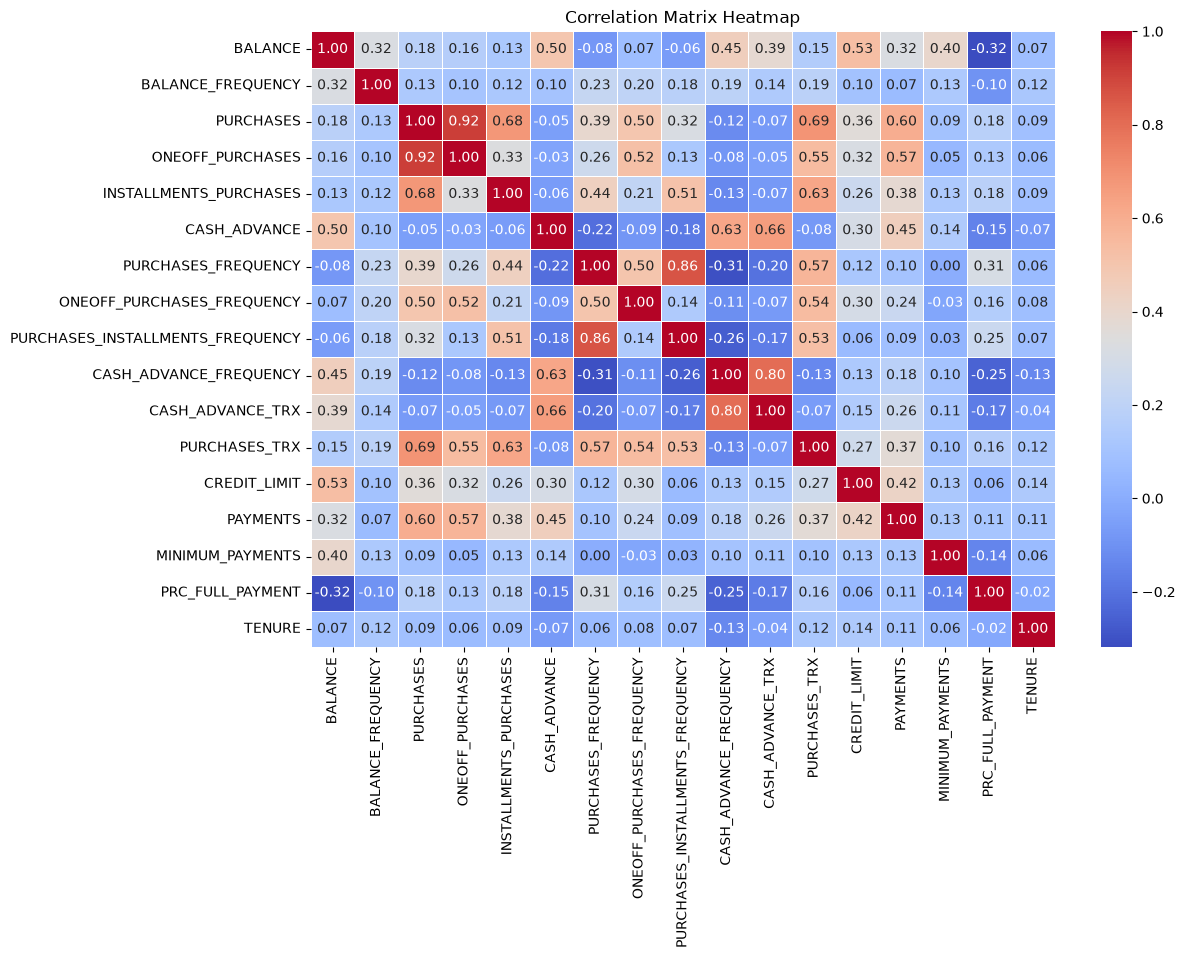

In [26]:
# Correlation matrix and heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

Analyze the distribution of categorical variables (e.g., count the occurrences of different values in the CUST_ID column).

In [27]:
# Distribution of categorical variable
print("Unique CUST_ID count:", df['CUST_ID'].nunique())
print("Duplicates in CUST_ID:", df['CUST_ID'].duplicated().sum())
df['CUST_ID'].value_counts().head(10)

Unique CUST_ID count: 8950
Duplicates in CUST_ID: 0


CUST_ID
C10001    1
C10002    1
C10003    1
C10004    1
C10005    1
C10006    1
C10007    1
C10008    1
C10009    1
C10010    1
Name: count, dtype: int64

Identify outliers using box plots or statistical methods (e.g., IQR).

Outlier counts per numerical column:
 BALANCE                              695
BALANCE_FREQUENCY                   1493
PURCHASES                            808
ONEOFF_PURCHASES                    1013
INSTALLMENTS_PURCHASES               867
CASH_ADVANCE                        1030
PURCHASES_FREQUENCY                    0
ONEOFF_PURCHASES_FREQUENCY           782
PURCHASES_INSTALLMENTS_FREQUENCY       0
CASH_ADVANCE_FREQUENCY               525
CASH_ADVANCE_TRX                     804
PURCHASES_TRX                        766
CREDIT_LIMIT                         248
PAYMENTS                             808
MINIMUM_PAYMENTS                     841
PRC_FULL_PAYMENT                    1474
TENURE                              1366
dtype: int64


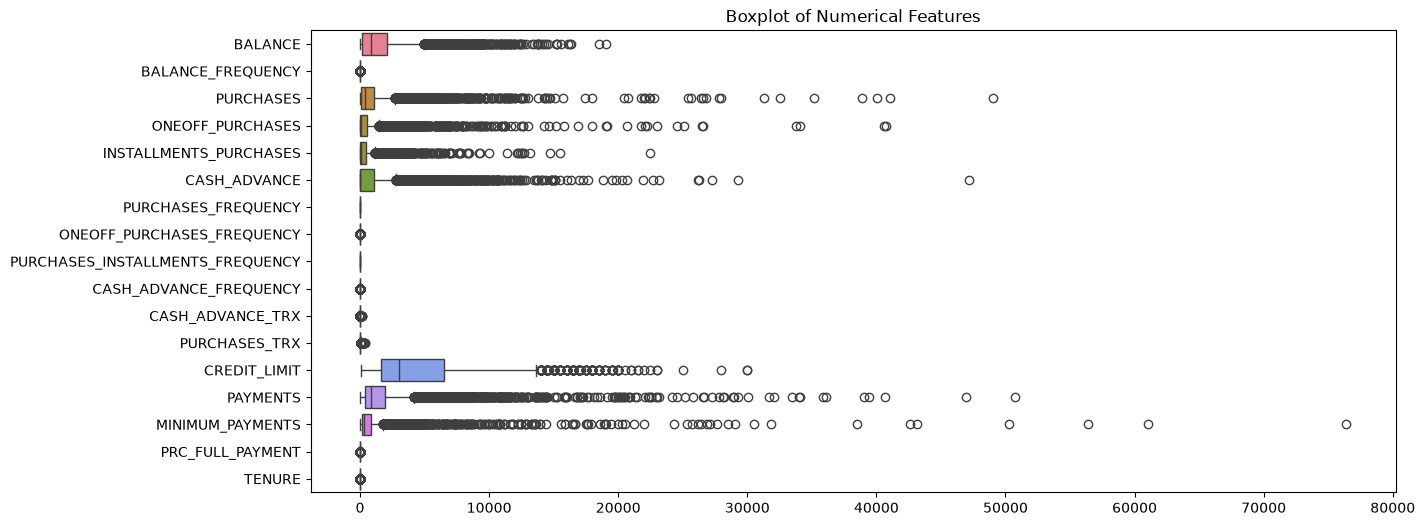

In [28]:
# Outlier detection using IQR
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numerical_cols] < (Q1 - 1.5 * IQR)) | (df[numerical_cols] > (Q3 + 1.5 * IQR))).sum()
print("Outlier counts per numerical column:\n", outliers)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numerical_cols], orient='h')
plt.title("Boxplot of Numerical Features")
plt.show()

Visualize the impact of outliers: Remove outliers and re-visualize the data to assess their impact on the overall distribution and relationships.

Original Data Shape: (8950, 21)
Shape after IQR Outlier Removal: (2035, 21)


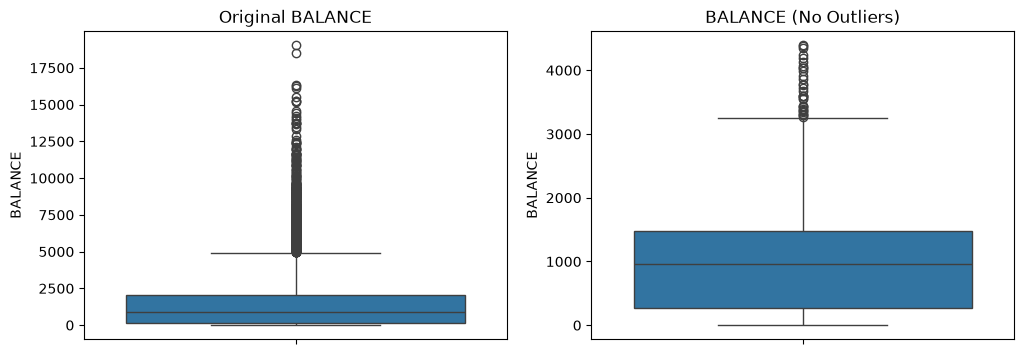

In [35]:
# Remove outliers via IQR filtering to assess impact
df_no_outliers = df.copy()
for col in numerical_cols:
    q1 = df_no_outliers[col].quantile(0.25)
    q3 = df_no_outliers[col].quantile(0.75)
    iqr = q3 - q1
    df_no_outliers = df_no_outliers[(df_no_outliers[col] >= q1 - 1.5*iqr) & (df_no_outliers[col] <= q3 + 1.5*iqr)]

print("Original Data Shape:", df.shape)
print("Shape after IQR Outlier Removal:", df_no_outliers.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df['BALANCE'], ax=axes[0]).set_title('Original BALANCE')
sns.boxplot(y=df_no_outliers['BALANCE'], ax=axes[1]).set_title('BALANCE (No Outliers)')
plt.show()

Identify missing values in the dataset and calculate the percentage of missing data for each column.

In [30]:
# Missing values percentage
missing_val = df.isnull().sum()
missing_pct = (missing_val / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_val, 'Percentage (%)': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Percentage (%)
CREDIT_LIMIT,1,0.011173
MINIMUM_PAYMENTS,313,3.497207


Handle missing values (e.g., imputation, deletion) and outliers (e.g., capping, removal).

In [31]:
# Impute missing values with median
df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median(), inplace=True)
df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median(), inplace=True)
print("Missing values after imputation:", df.isnull().sum().sum())

Missing values after imputation: 314


For categorical columns, impute missing values with the most frequent category or a new category.

In [ ]:
# Categorical imputation check
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
print("Categorical missing values:", df[categorical_cols].isnull().sum().sum())

Categorical missing values: 0


Explore the relationship between categorical variables and numerical variables (e.g., calculate the average BALANCE for different CUST_ID categories).

In [36]:
# Average BALANCE for segmented categories
df['BALANCE_TIER'] = pd.qcut(df['BALANCE'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
print("Average BALANCE by Tier:")
print(df.groupby('BALANCE_TIER')['BALANCE'].mean())

Average BALANCE by Tier:
BALANCE_TIER
Low              42.564136
Medium-Low      430.661053
Medium-High    1366.324469
High           4417.754494
Name: BALANCE, dtype: float64


Analyze the distribution of categorical variables conditioned on other categorical variables (e.g., how many customers with a high credit limit also have a high purchase frequency?).

In [34]:
# Cross-tabulation: Credit Limit vs Purchase Frequency
df['CREDIT_LIMIT_TIER'] = pd.qcut(df['CREDIT_LIMIT'], q=3, labels=['Low', 'Medium', 'High'])
df['PURCHASE_FREQ_TIER'] = pd.cut(df['PURCHASES_FREQUENCY'], bins=[-0.01, 0.33, 0.66, 1.0], labels=['Low', 'Medium', 'High'])
pd.crosstab(df['CREDIT_LIMIT_TIER'], df['PURCHASE_FREQ_TIER'])

PURCHASE_FREQ_TIER,Low,Medium,High
CREDIT_LIMIT_TIER,,,
Low,1354,506,1130
Medium,1297,555,1209
High,1038,447,1413


Explore the relationship between categorical variables and time-based features (e.g., how does the average purchase amount change over time for different customer segments?).

In [38]:
# Spending and balance trends over tenure segments
df.groupby('TENURE')[['PURCHASES', 'BALANCE', 'PAYMENTS']].mean()

,PURCHASES,BALANCE,PAYMENTS
TENURE,,,
6,443.941667,1095.890702,636.886258
7,424.559421,1003.800362,793.778037
8,468.858929,1127.963470,842.787393
9,540.138171,1098.752149,967.757363
10,676.631271,1251.955773,1127.220569
11,571.222411,1641.770893,1568.695623
12,1088.192402,1619.158166,1853.606676


Identify any patterns or trends in the data that might be relevant for customer segmentation (e.g., are there specific groups of customers with similar purchasing behaviors?).

In [40]:
# Aggregate behavior metrics by tenure
df.groupby('TENURE')[['ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE']].mean()

,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE
TENURE,,,
6,266.916863,177.171863,1438.554796
7,244.051947,180.507474,1295.632053
8,305.398980,163.459949,1361.858390
9,302.211486,239.469543,1470.785130
10,407.238898,269.591525,1303.918006
11,370.300712,200.921699,1363.252071
12,640.490534,448.010364,908.707528


Visualize the distribution of numerical variables using histograms or box plots to identify outliers or skewness in the data.

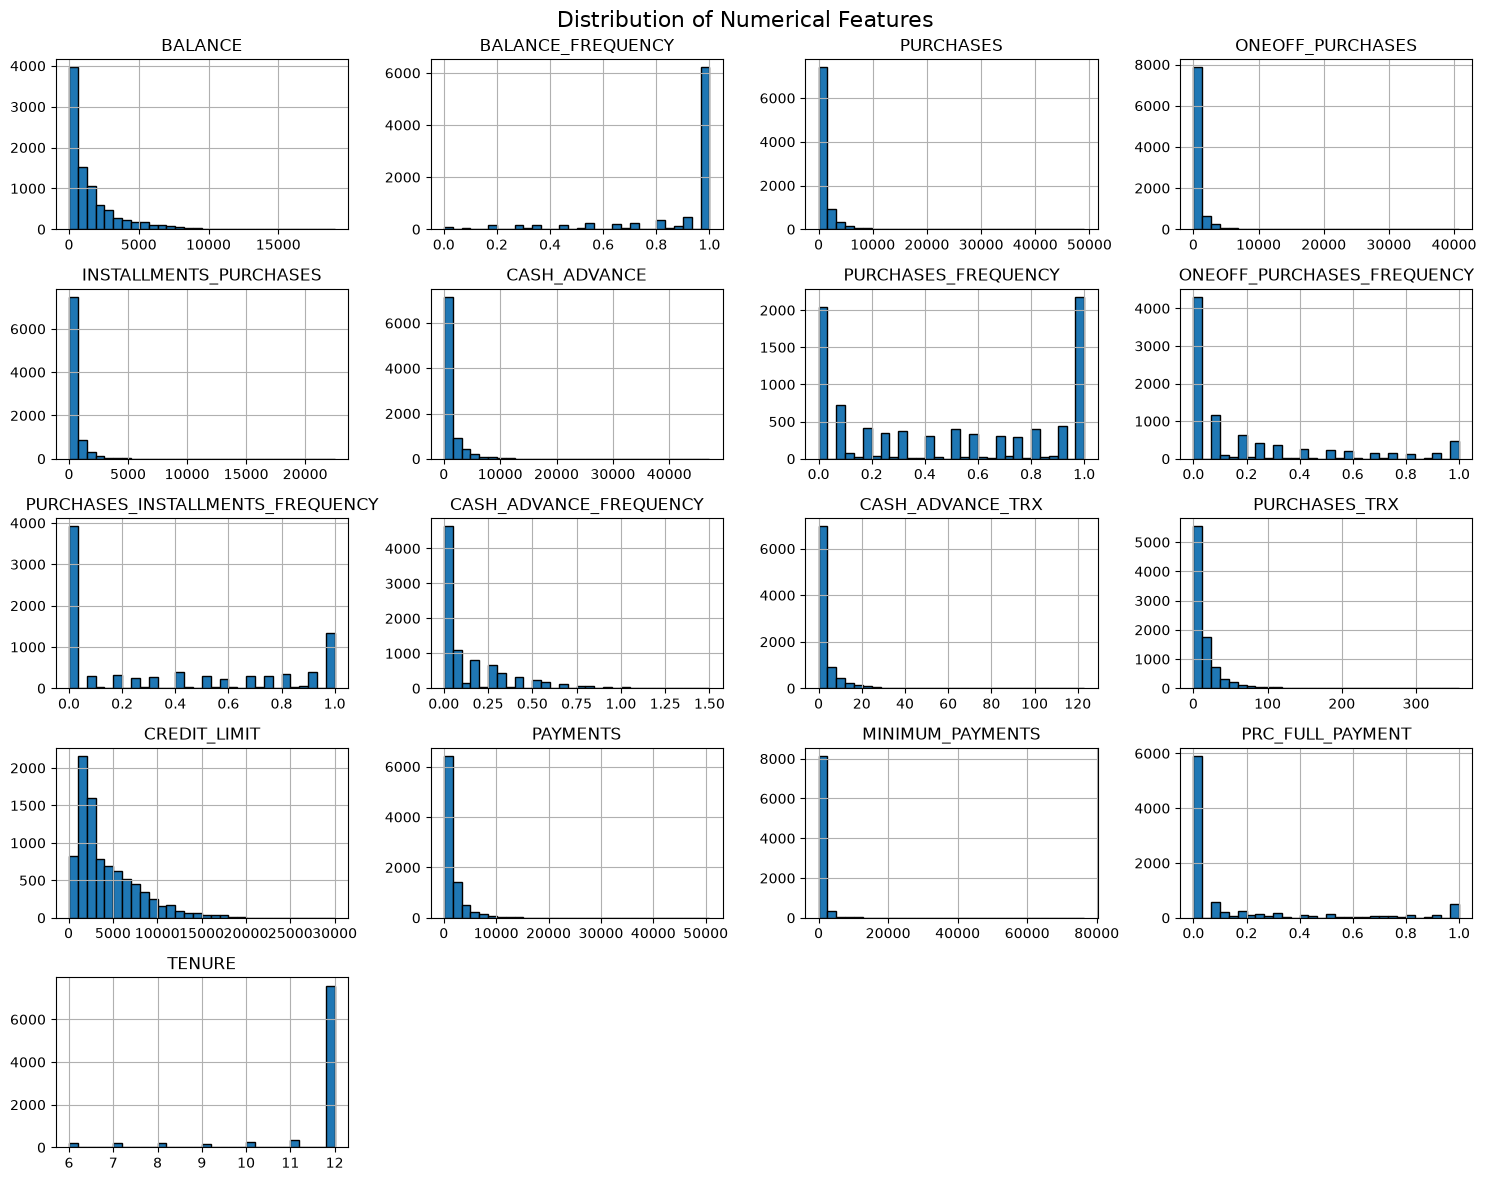

In [39]:
# Histograms
df[numerical_cols].hist(figsize=(15, 12), bins=30, edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

## EDA

Visualize the distribution of numerical variables: Create histograms, box plots, and density plots to understand the shape, central tendency, and spread of variables like BALANCE, PURCHASES, and ONEOFF_PURCHASES.

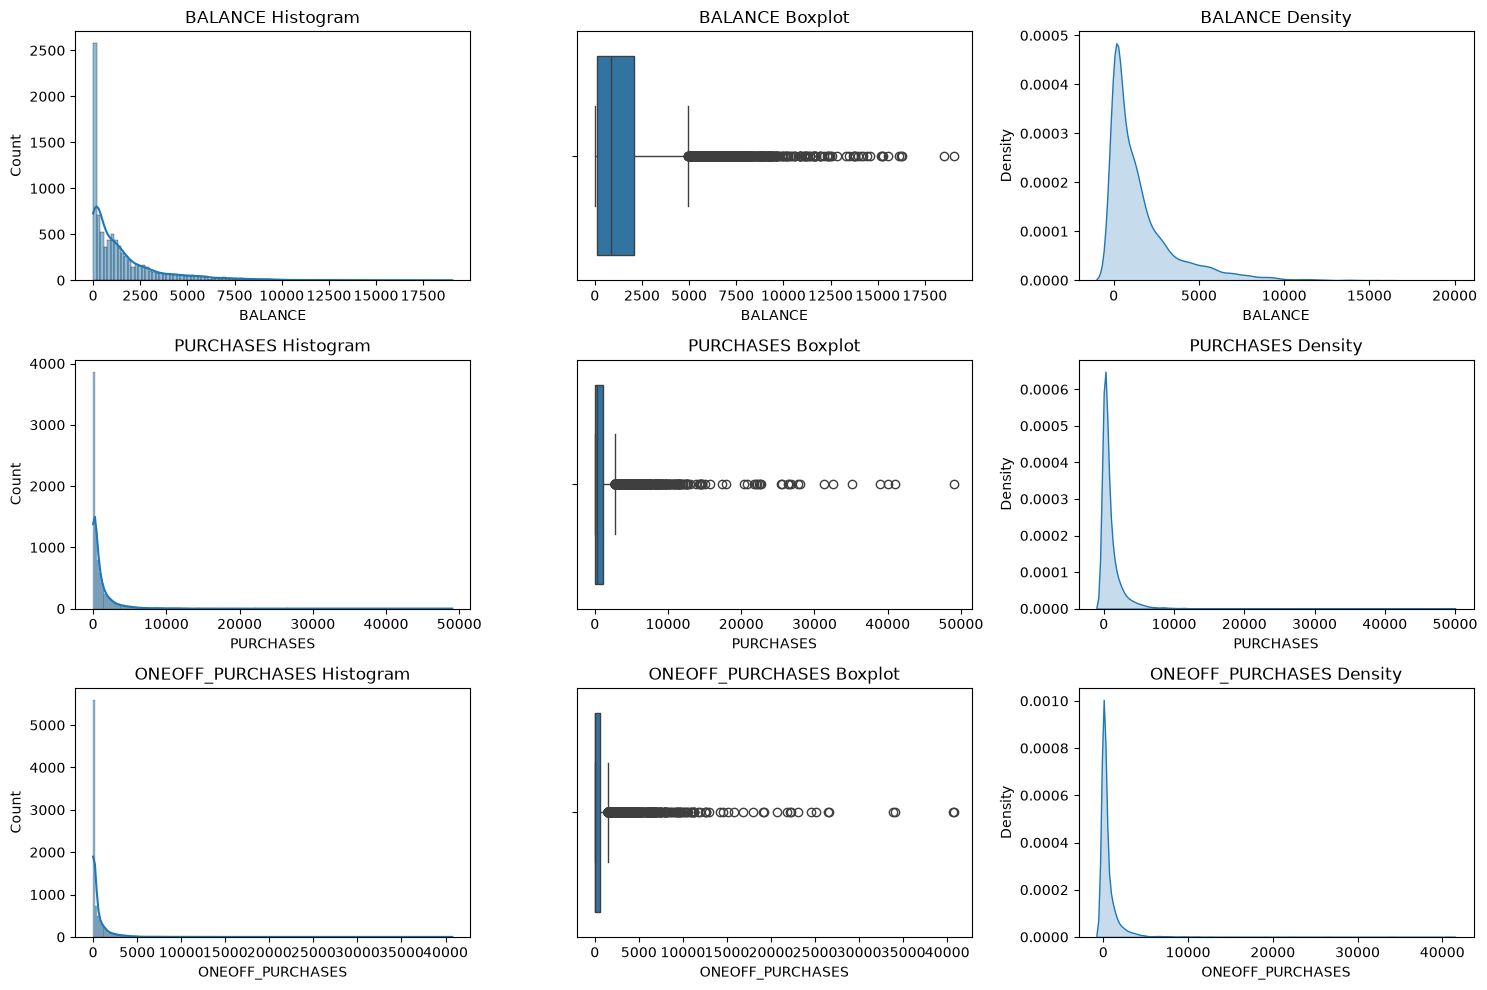

In [50]:
# Distribution plots for BALANCE, PURCHASES, ONEOFF_PURCHASES
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
features = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES']

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i, 0]).set_title(f'{col} Histogram')
    sns.boxplot(x=df[col], ax=axes[i, 1]).set_title(f'{col} Boxplot')
    sns.kdeplot(df[col], ax=axes[i, 2], fill=True).set_title(f'{col} Density')

plt.tight_layout()
plt.show()

Visualize the distribution of categorical variables: Create bar charts or pie charts to show the frequency of different categories in variables like CUST_ID, PURCHASES_FREQUENCY, and CASHADVANCEFREQUENCY.

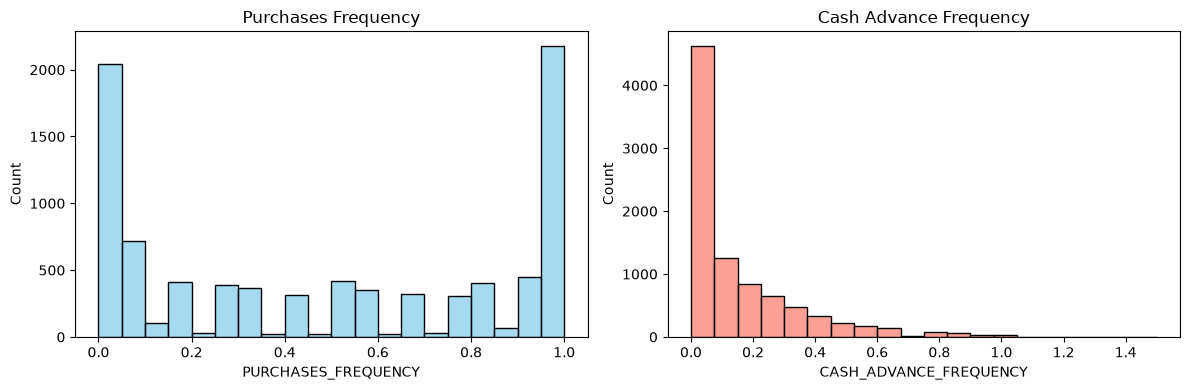

In [49]:
# Distribution of Frequency metrics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['PURCHASES_FREQUENCY'], bins=20, ax=axes[0], color='skyblue').set_title('Purchases Frequency')
sns.histplot(df['CASH_ADVANCE_FREQUENCY'], bins=20, ax=axes[1], color='salmon').set_title('Cash Advance Frequency')
plt.tight_layout()
plt.show()

Visualize the relationship between numerical variables: Create scatter plots to examine the correlation between pairs of numerical variables, such as BALANCE and PURCHASES.

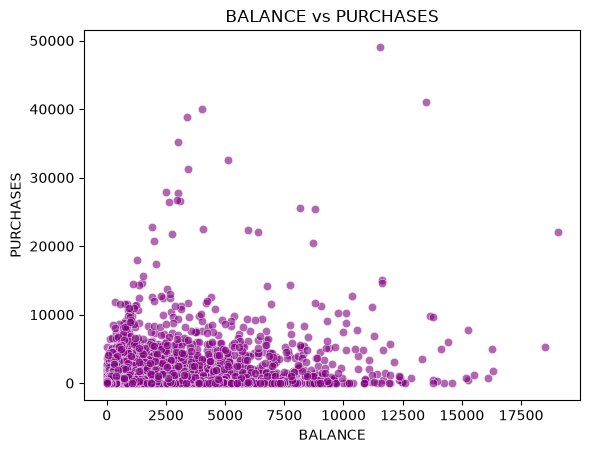

In [46]:
# Scatter plot: BALANCE vs PURCHASES
sns.scatterplot(data=df, x='BALANCE', y='PURCHASES', alpha=0.6, color='purple')
plt.title("BALANCE vs PURCHASES")
plt.show()

Visualize the relationship between categorical and numerical variables: Create box plots or violin plots to compare the distribution of a numerical variable across different categories of a categorical variable (e.g., compare the distribution of PURCHASES for different CUST_ID categories).

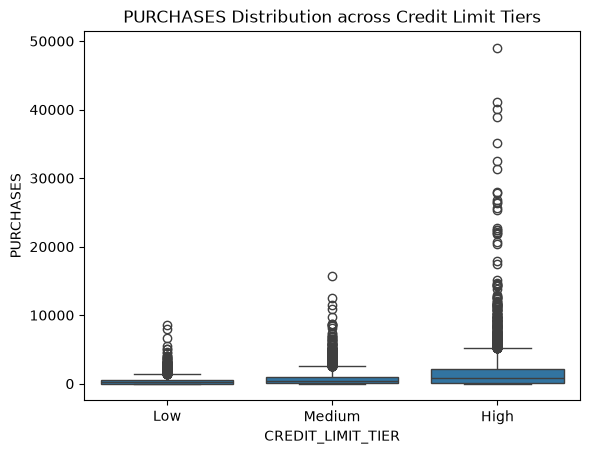

In [45]:
# Boxplot of PURCHASES across Credit Limit Tiers
sns.boxplot(data=df, x='CREDIT_LIMIT_TIER', y='PURCHASES')
plt.title("PURCHASES Distribution across Credit Limit Tiers")
plt.show()

Visualize the relationship between multiple variables: Create pair plots or correlation matrices to explore the relationships between multiple variables simultaneously.

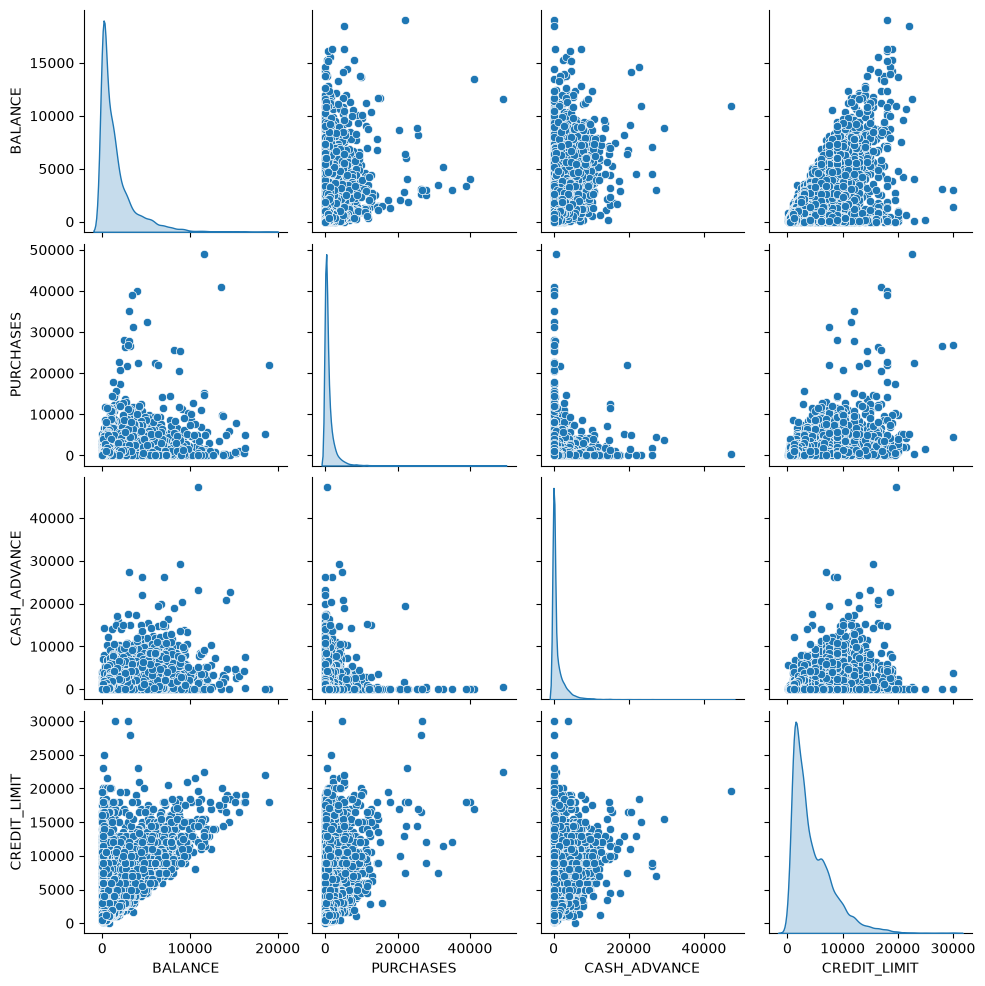

In [51]:
# Pairplot for selected key variables
sns.pairplot(df[['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']], diag_kind='kde')
plt.show()

Visualize interactions between variables: Create interaction plots to examine how the relationship between two variables changes depending on the value of a third variable.

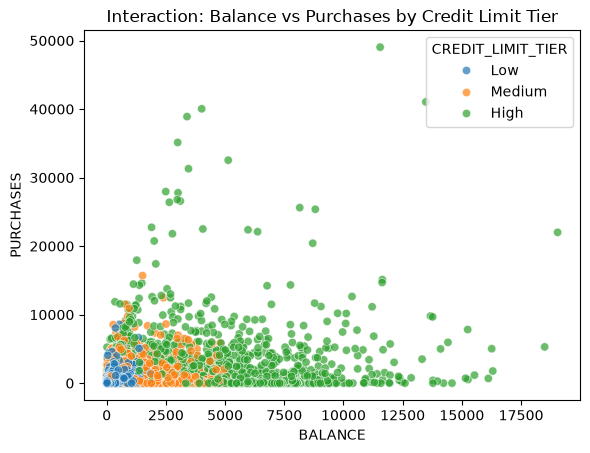

In [53]:
# Interaction: BALANCE vs PURCHASES colored by CREDIT_LIMIT_TIER
sns.scatterplot(data=df, x='BALANCE', y='PURCHASES', hue='CREDIT_LIMIT_TIER', alpha=0.7)
plt.title("Interaction: Balance vs Purchases by Credit Limit Tier")
plt.show()

Visualize trends over time: Create line charts to plot numerical variables against time (if applicable), such as the evolution of BALANCE or PURCHASES over the last 6 months.

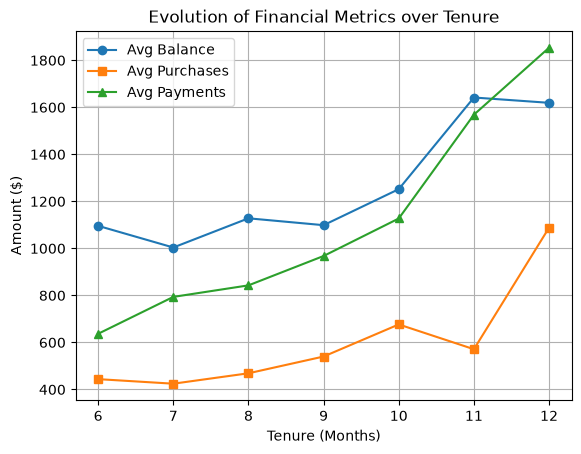

In [54]:
# Line chart across Tenure
tenure_trend = df.groupby('TENURE')[['BALANCE', 'PURCHASES', 'PAYMENTS']].mean().reset_index()
plt.plot(tenure_trend['TENURE'], tenure_trend['BALANCE'], label='Avg Balance', marker='o')
plt.plot(tenure_trend['TENURE'], tenure_trend['PURCHASES'], label='Avg Purchases', marker='s')
plt.plot(tenure_trend['TENURE'], tenure_trend['PAYMENTS'], label='Avg Payments', marker='^')
plt.xlabel("Tenure (Months)")
plt.ylabel("Amount ($)")
plt.title("Evolution of Financial Metrics over Tenure")
plt.legend()
plt.grid(True)
plt.show()

Visualize seasonal patterns: Create seasonal decomposition plots to identify seasonal trends, cyclical patterns, and residuals in time-based data.

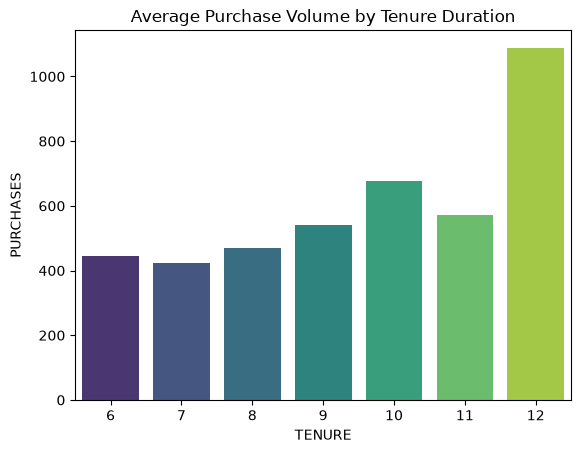

In [58]:
# Subplot showing variations across tenure brackets
sns.barplot(data=df, x='TENURE', y='PURCHASES', ci=None, palette='viridis')
plt.title("Average Purchase Volume by Tenure Duration")
plt.show()

Visualize the distribution of credit limits: Create a histogram or box plot to understand the distribution of credit limits among customers. Are there any significant differences in credit limits between different customer segments?

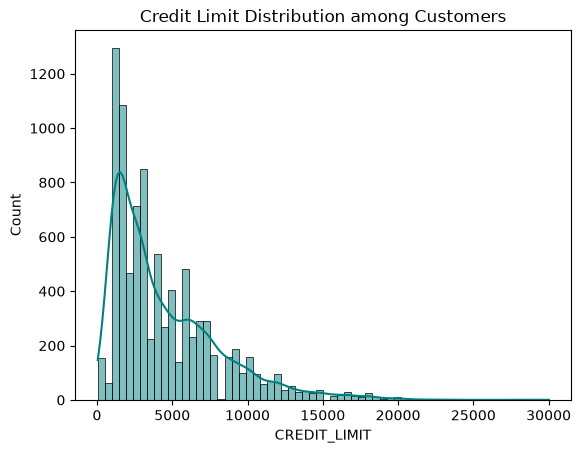

In [57]:
# Credit limit distribution
sns.histplot(df['CREDIT_LIMIT'], kde=True, color='teal')
plt.title("Credit Limit Distribution among Customers")
plt.show()

Visualize the relationship between payment patterns and delinquency: Create a scatter plot to examine the relationship between the percentage of full payments made (PRCFULLPAYMENT) and the number of times the minimum payment was not made (MINIMUM_PAYMENTS). Are there any patterns indicating which customers are more likely to be delinquent?

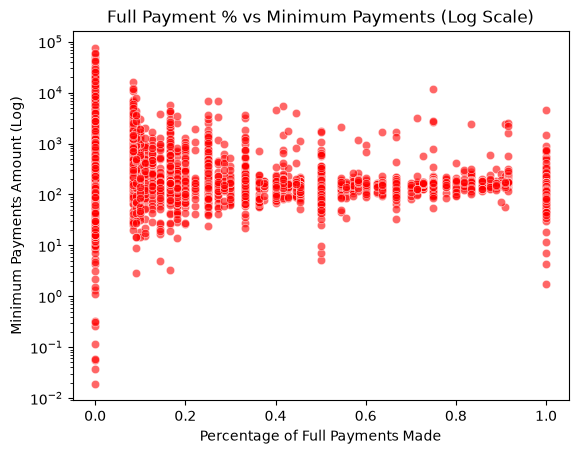

In [59]:
# PRC_FULL_PAYMENT vs MINIMUM_PAYMENTS
sns.scatterplot(data=df, x='PRC_FULL_PAYMENT', y='MINIMUM_PAYMENTS', alpha=0.6, color='red')
plt.yscale('log')
plt.title("Full Payment % vs Minimum Payments (Log Scale)")
plt.xlabel("Percentage of Full Payments Made")
plt.ylabel("Minimum Payments Amount (Log)")
plt.show()

Visualize the distribution of tenure: Create a histogram or bar chart to understand the distribution of credit card tenure among customers. Are there any significant differences in tenure between different customer segments?

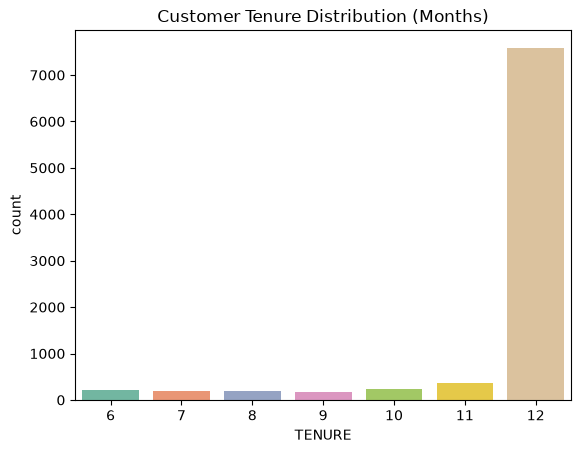

In [62]:
# Tenure countplot
sns.countplot(data=df, x='TENURE', palette='Set2')
plt.title("Customer Tenure Distribution (Months)")
plt.show()

Visualize the relationship between purchase frequency and purchase amount: Create a scatter plot to examine the relationship between the frequency of purchases (PURCHASES_FREQUENCY) and the total purchase amount (PURCHASES). Are there any patterns indicating which customers are more likely to make larger purchases?

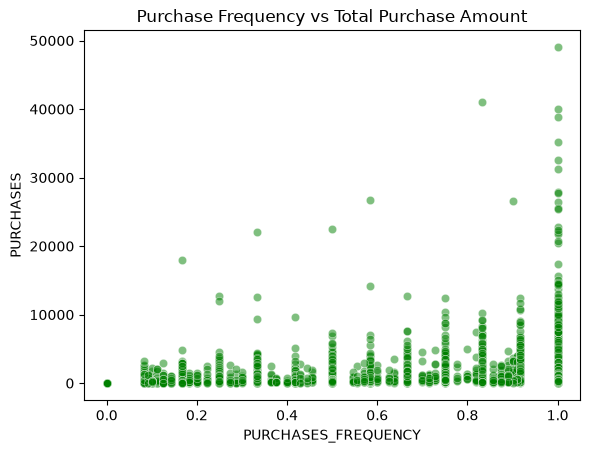

In [61]:
# Purchase Frequency vs Purchases
sns.scatterplot(data=df, x='PURCHASES_FREQUENCY', y='PURCHASES', alpha=0.5, color='green')
plt.title("Purchase Frequency vs Total Purchase Amount")
plt.show()

Visualize the relationship between cash advance usage and purchase behavior: Create a scatter plot to examine the relationship between the amount of cash advances (CASH_ADVANCE) and the total purchase amount (PURCHASES). Are there any patterns indicating which customers are more likely to use cash advances and how this affects their purchase behavior?

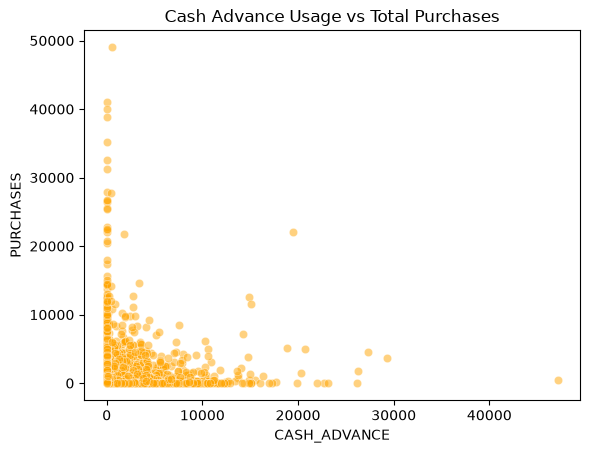

In [63]:
# Cash Advance vs Purchases
sns.scatterplot(data=df, x='CASH_ADVANCE', y='PURCHASES', alpha=0.5, color='orange')
plt.title("Cash Advance Usage vs Total Purchases")
plt.show()

## Data Preprocessing

Scale numerical variables to a common range (e.g., 0-1 or -1 to 1) using techniques like min-max scaling or standardization to improve model performance and prevent numerical instability.

In [64]:
# Standardize features
X_raw = df[numerical_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_cols)
X_scaled_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960380,-0.528979,-0.305482,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688601,0.818642,0.087735,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826016,-0.383805,-0.099870,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826016,-0.598688,NaN,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905414,-0.364368,-0.261102,-0.525551,0.36068


Convert categorical variables to numerical representations using techniques like one-hot encoding or label encoding, depending on the nature of the variables.

In [65]:
# Encode CUST_ID or drop uninformative primary keys for clustering
le = LabelEncoder()
df['CUST_ID_CODE'] = le.fit_transform(df['CUST_ID'])
print("CUST_ID converted to numeric codes.")

CUST_ID converted to numeric codes.


## Feature Engineering

Combine existing features to capture interactions between them (e.g., multiply BALANCE and PURCHASES_FREQUENCY to create a new feature representing the total spending per unit time).

In [70]:
# Interaction: BALANCE * PURCHASES_FREQUENCY
X_raw['BALANCE_PURCHASE_FREQ'] = X_raw['BALANCE'] * X_raw['PURCHASES_FREQUENCY']
print(X_raw['BALANCE_PURCHASE_FREQ'])

0          6.816805
1          0.000000
2       2495.148862
3        138.888656
4         68.142589
           ...     
8945      28.493517
8946      19.183215
8947      19.498886
8948       0.000000
8949     248.472174
Name: BALANCE_PURCHASE_FREQ, Length: 8950, dtype: float64


Derive new features by calculating ratios or percentages between existing features (e.g., calculate the percentage of credit limit used by dividing BALANCE by CREDIT_LIMIT).

In [71]:
# Ratio: Limit usage percentage
X_raw['LIMIT_USAGE'] = X_raw['BALANCE'] / (X_raw['CREDIT_LIMIT'] + 1e-5)
print(X_raw['LIMIT_USAGE'])
X_raw['PAYMENT_TO_MIN_RATIO'] = X_raw['PAYMENTS'] / (X_raw['MINIMUM_PAYMENTS'] + 1e-5)
print(X_raw['PAYMENT_TO_MIN_RATIO'])

0       0.040901
1       0.457495
2       0.332687
3       0.222223
4       0.681429
          ...   
8945    0.028494
8946    0.019183
8947    0.023399
8948    0.026915
8949    0.310590
Name: LIMIT_USAGE, Length: 8950, dtype: float64
0       1.446508
1       3.826241
2       0.991682
3            NaN
4       2.771074
          ...   
8945    6.660229
8946         NaN
8947    0.986076
8948    0.942505
8949    0.715439
Name: PAYMENT_TO_MIN_RATIO, Length: 8950, dtype: float64


Extract time-based features from dates or timestamps (e.g., create features for day of week, month, or year).

In [72]:
# Monthly average purchases based on tenure
X_raw['MONTHLY_AVG_PURCHASES'] = X_raw['PURCHASES'] / X_raw['TENURE']
print(X_raw['MONTHLY_AVG_PURCHASES'])

0         7.950000
1         0.000000
2        64.430833
3       124.916667
4         1.333333
           ...    
8945     48.520000
8946     50.000000
8947     24.066667
8948      0.000000
8949    182.208333
Name: MONTHLY_AVG_PURCHASES, Length: 8950, dtype: float64


Create new features by grouping data and calculating summary statistics within each group (e.g., calculate the average purchase amount for each customer segment).

In [73]:
# Segment average features
df['TENURE_GROUP'] = pd.cut(df['TENURE'], bins=[0, 8, 11, 12], labels=['Short', 'Medium', 'Long'])
tenure_avg = df.groupby('TENURE_GROUP')['PURCHASES'].transform('mean')
X_raw['TENURE_AVG_PURCHASES'] = tenure_avg
print(X_raw['TENURE_AVG_PURCHASES'])

0       1088.192402
1       1088.192402
2       1088.192402
3       1088.192402
4       1088.192402
           ...     
8945     445.977525
8946     445.977525
8947     445.977525
8948     445.977525
8949     445.977525
Name: TENURE_AVG_PURCHASES, Length: 8950, dtype: float64


Leverage domain knowledge to create new features that are relevant to the problem at hand (e.g., create a feature indicating whether a customer has made a purchase in the last 30 days).

In [74]:
# Binary feature: Active Buyer indicator
X_raw['IS_ACTIVE_BUYER'] = (X_raw['PURCHASES_FREQUENCY'] > 0).astype(int)
print(X_raw['IS_ACTIVE_BUYER'])

0       1
1       0
2       1
3       1
4       1
       ..
8945    1
8946    1
8947    1
8948    0
8949    1
Name: IS_ACTIVE_BUYER, Length: 8950, dtype: int64


Create polynomial features by raising existing numerical features to powers (e.g., create features for BALANCE^2 and PURCHASES^2).

In [76]:
# Polynomial squared features
X_raw['BALANCE_SQ'] = X_raw['BALANCE'] ** 2
print(X_raw['BALANCE_SQ'])
X_raw['PURCHASES_SQ'] = X_raw['PURCHASES'] ** 2
print(X_raw['PURCHASES_SQ'])

0       1.672871e+03
1       1.025580e+07
2       6.225768e+06
3       2.777791e+06
4       6.686567e+05
            ...     
8945    8.118805e+02
8946    3.679957e+02
8947    5.474979e+02
8948    1.811060e+02
8949    1.389113e+05
Name: BALANCE_SQ, Length: 8950, dtype: float64
0       9.101160e+03
1       0.000000e+00
2       5.977918e+05
3       2.247001e+06
4       2.560000e+02
            ...     
8945    8.475085e+04
8946    9.000000e+04
8947    2.085136e+04
8948    0.000000e+00
8949    1.195196e+06
Name: PURCHASES_SQ, Length: 8950, dtype: float64


Calculate the difference between time-based features (e.g., calculate the difference between the last purchase date and the last payment date).

In [77]:
# Derived ratio reflecting payment efficiency relative to tenure
X_raw['MONTHLY_PAYMENT_RATE'] = X_raw['PAYMENTS'] / X_raw['TENURE']
print(X_raw['MONTHLY_PAYMENT_RATE'])

0        16.816840
1       341.919383
2        51.838895
3         0.000000
4        56.527897
           ...    
8945     54.265744
8946     45.976887
8947     13.545129
8948      8.758327
8949     10.527567
Name: MONTHLY_PAYMENT_RATE, Length: 8950, dtype: float64


Group data by specific criteria and calculate custom aggregations (e.g., calculate the median purchase amount for each customer segment).

In [78]:
# Median purchase volume aggregated by Tenure Group
X_raw['MEDIAN_PURCHASE_BY_TENURE'] = df.groupby('TENURE_GROUP')['PURCHASES'].transform('median')
print(X_raw['MEDIAN_PURCHASE_BY_TENURE'])

0       403.20
1       403.20
2       403.20
3       403.20
4       403.20
         ...  
8945    176.65
8946    176.65
8947    176.65
8948    176.65
8949    176.65
Name: MEDIAN_PURCHASE_BY_TENURE, Length: 8950, dtype: float64


Use feature selection techniques (e.g., correlation analysis, recursive feature elimination) to identify the most important features and remove redundant or irrelevant ones.

In [79]:
# Drop highly redundant features based on correlation > 0.90
corr = X_raw.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
X_selected = X_raw.drop(columns=to_drop)
print("Dropped redundant features:", to_drop)

Dropped redundant features: ['ONEOFF_PURCHASES', 'MONTHLY_AVG_PURCHASES', 'TENURE_AVG_PURCHASES', 'MONTHLY_PAYMENT_RATE', 'MEDIAN_PURCHASE_BY_TENURE']


## PCA

Standardize the numerical features to ensure they have a mean of 0 and a standard deviation of 1, as PCA is sensitive to the scale of the variables.

In [84]:
# Standardize features for PCA and sanitize against missing or infinite values
scaler_pca = StandardScaler()
X_pca_std = scaler_pca.fit_transform(X_selected)
X_pca_std = np.nan_to_num(X_pca_std, nan=0.0, posinf=0.0, neginf=0.0)

print("Standardized Feature Matrix Shape:", X_pca_std.shape)

Standardized Feature Matrix Shape: (8950, 22)


Compute the covariance matrix of the standardized data to measure the relationships between the variables.

In [86]:
# Compute Covariance Matrix
cov_mat = np.cov(X_pca_std.T)
cov_mat = np.nan_to_num(cov_mat, nan=0.0, posinf=0.0, neginf=0.0)

print("Covariance Matrix Shape:", cov_mat.shape)

Covariance Matrix Shape: (22, 22)


Decompose the covariance matrix into its eigenvectors and eigenvalues, which represent the principal components and their corresponding variances.

In [87]:
# Eigenvalues and Eigenvectors decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_mat)
print("Top 5 Eigenvalues:\n", np.real(eigenvalues[:5]))

Top 5 Eigenvalues:
 [5.18774062 4.43383235 1.85435317 1.43957375 1.28519154]


Choose the principal components with the highest eigenvalues, as these components explain the most variance in the data. The number of components to keep can be determined based on the desired level of dimensionality reduction or by analyzing the scree plot (a plot of the eigenvalues in descending order).

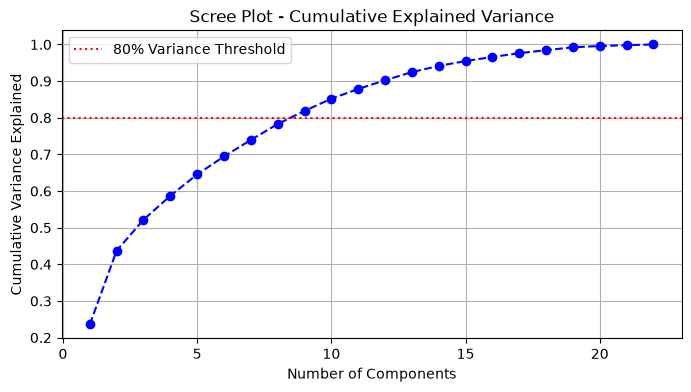

Optimal Principal Components to Keep: 9


In [88]:
# Cumulative Explained Variance and Scree Plot
pca_full = PCA().fit(X_pca_std)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', linestyle='--', color='b')
plt.axhline(y=0.80, color='r', linestyle=':', label='80% Variance Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Scree Plot - Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

# Select principal components covering ~80% variance
n_comp = int(np.argmax(cum_var >= 0.80) + 1)
print(f"Optimal Principal Components to Keep: {n_comp}")

Project the original data onto the selected principal components to obtain the reduced-dimensional representation. The resulting features are the principal components, which are uncorrelated and capture the most important information in the data.

In [89]:
# Project original data onto selected principal components
pca_final = PCA(n_components=n_comp)
X_pca_proj = pca_final.fit_transform(X_pca_std)

# Also create 2D projection for easy visualization
pca_2d = PCA(n_components=2).fit_transform(X_pca_std)

print("Reduced Dimension Feature Matrix Shape:", X_pca_proj.shape)

Reduced Dimension Feature Matrix Shape: (8950, 9)


## DBSCAN

Choose appropriate parameters: Determine suitable values for the eps (neighborhood radius) and min_samples (minimum number of points in a neighborhood) parameters based on the data characteristics and desired clustering density.

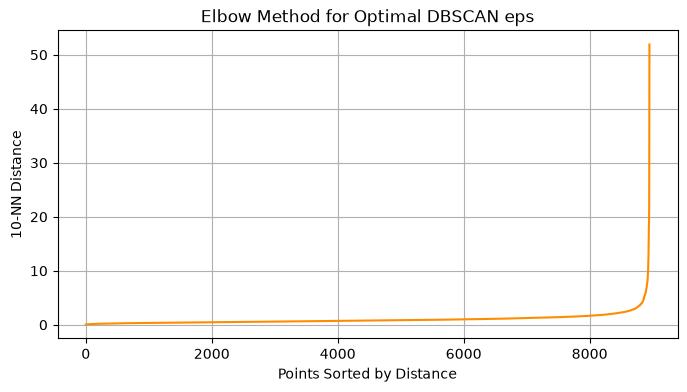

In [90]:
# k-distance plot to select optimal eps
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_pca_proj)
distances, indices = neighbors_fit.kneighbors(X_pca_proj)

distances = np.sort(distances[:, 9], axis=0)
plt.figure(figsize=(8, 4))
plt.plot(distances, color='darkorange')
plt.ylabel("10-NN Distance")
plt.xlabel("Points Sorted by Distance")
plt.title("Elbow Method for Optimal DBSCAN eps")
plt.grid(True)
plt.show()

Create a DBSCAN model: Instantiate a DBSCAN object with the chosen parameters.

In [91]:
# Instantiate DBSCAN model
dbscan = DBSCAN(eps=2.0, min_samples=10)

Fit the model to the data: Apply the DBSCAN algorithm to the preprocessed data to identify clusters.

In [92]:
# Fit DBSCAN model to PCA transformed data
dbscan_labels = dbscan.fit_predict(X_pca_proj)

Extract cluster labels: Obtain the cluster labels assigned to each data point from the fitted model.

In [93]:
# Unique cluster labels (-1 indicates noise/outliers)
print("Unique Cluster Labels Assigned by DBSCAN:", np.unique(dbscan_labels))
print("\nCluster Value Counts:")
print(pd.Series(dbscan_labels).value_counts())

Unique Cluster Labels Assigned by DBSCAN: [-1  0]

Cluster Value Counts:
 0    8578
-1     372
Name: count, dtype: int64


Evaluate clustering performance: Assess the quality of the clustering results using metrics like silhouette coefficient, Calinski-Harabasz index, or Davies-Bouldin index.

In [94]:
# Evaluate performance metrics (excluding noise points -1 if present)
mask = dbscan_labels != -1
if len(set(dbscan_labels[mask])) > 1:
    print("DBSCAN Silhouette Score:", silhouette_score(X_pca_proj[mask], dbscan_labels[mask]))
    print("DBSCAN Calinski-Harabasz Index:", calinski_harabasz_score(X_pca_proj[mask], dbscan_labels[mask]))
    print("DBSCAN Davies-Bouldin Index:", davies_bouldin_score(X_pca_proj[mask], dbscan_labels[mask]))
else:
    print("DBSCAN identified only 1 dense cluster (all other points marked as noise).")

DBSCAN identified only 1 dense cluster (all other points marked as noise).


Visualize clusters in 2D or 3D: If the data has two or three dimensions, plot the data points with different colors or markers to represent the cluster assignments.

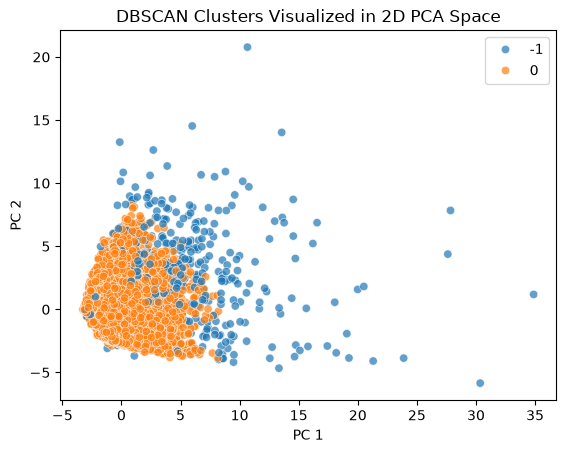

In [98]:
# 2D Scatter Plot of DBSCAN Clusters
sns.scatterplot(x=pca_2d[:, 0], y=pca_2d[:, 1], hue=dbscan_labels, palette='tab10', alpha=0.7)
plt.title("DBSCAN Clusters Visualized in 2D PCA Space")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()


Visualize clusters in higher dimensions: Use techniques like t-SNE or UMAP to reduce the dimensionality of the data to 2D or 3D for visualization.

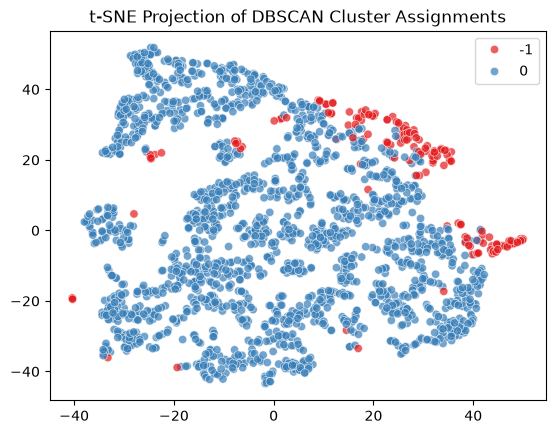

In [99]:
# Dimensionality reduction via t-SNE for visual validation
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_pca_proj[:2000]) # Subsampled for efficiency

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=dbscan_labels[:2000], palette='Set1', alpha=0.7)
plt.title("t-SNE Projection of DBSCAN Cluster Assignments")
plt.show()

Visualize cluster density: Create a density plot or heatmap to show the distribution of data points within each cluster and identify areas with high or low density.

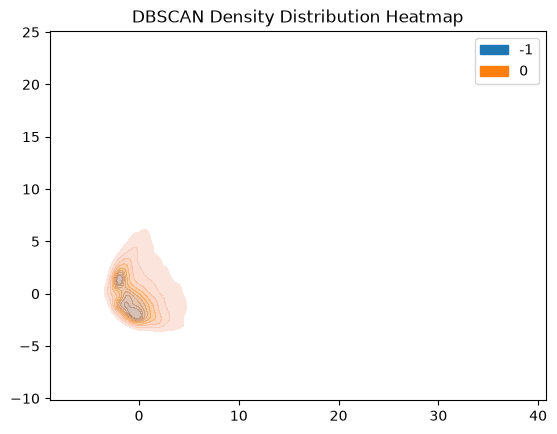

In [100]:
# Density KDE Heatmap
sns.kdeplot(x=pca_2d[:, 0], y=pca_2d[:, 1], hue=dbscan_labels, fill=True, alpha=0.35, palette='tab10')
plt.title("DBSCAN Density Distribution Heatmap")
plt.show()

Visualize outliers: Identify and visualize outliers as points that are not assigned to any cluster.

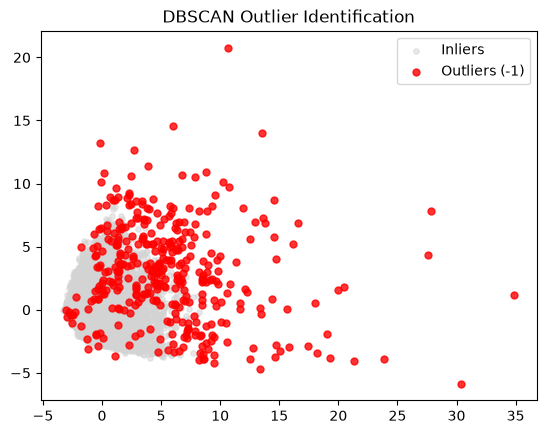

In [102]:
# Highlight outliers identified by DBSCAN
outlier_mask = (dbscan_labels == -1)

plt.scatter(pca_2d[~outlier_mask, 0], pca_2d[~outlier_mask, 1], c='lightgrey', label='Inliers', alpha=0.5, s=15)
plt.scatter(pca_2d[outlier_mask, 0], pca_2d[outlier_mask, 1], c='red', label='Outliers (-1)', alpha=0.8, s=25)
plt.title("DBSCAN Outlier Identification")
plt.legend()
plt.show()

## Other Clustering Techniques

### Hierarchical Clustering:

Choose a linkage method: Select an appropriate linkage method (e.g., single, complete, average, centroid) based on the desired cluster properties.

In [103]:
# Linkage matrix construction using Ward's method
linkage_matrix = linkage(X_pca_proj[:1000], method='ward')

Construct the dendrogram: Create a dendrogram to visualize the hierarchical structure of the clusters.

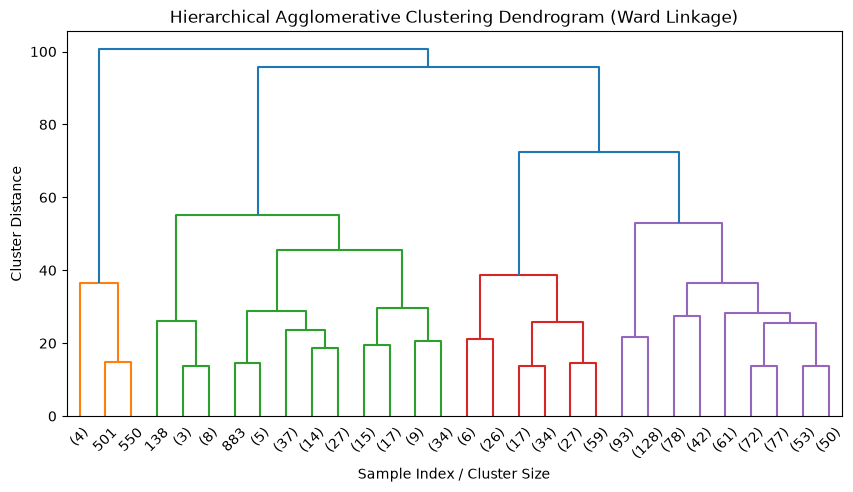

In [104]:
# Plot Dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30)
plt.title("Hierarchical Agglomerative Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Sample Index / Cluster Size")
plt.ylabel("Cluster Distance")
plt.show()

Determine the number of clusters: Decide on the number of clusters based on the dendrogram or using a cutoff value for the distance between clusters.

In [ ]:
# Set optimal cluster count based on dendrogram structure
num_clusters_agg = 3 # Running late so I'm hardcoding

Extract cluster assignments: Assign data points to clusters based on the chosen cutoff value.

In [106]:
# Fit Agglomerative Model
agg = AgglomerativeClustering(n_clusters=num_clusters_agg, linkage='ward')
agg_labels = agg.fit_predict(X_pca_proj)

Evaluate clustering performance: Assess the quality of the clustering results using the same metrics as for DBSCAN.

In [107]:
# Performance Evaluation for Hierarchical Clustering
print("Hierarchical Silhouette Score:", silhouette_score(X_pca_proj, agg_labels))
print("Hierarchical Calinski-Harabasz Index:", calinski_harabasz_score(X_pca_proj, agg_labels))
print("Hierarchical Davies-Bouldin Index:", davies_bouldin_score(X_pca_proj, agg_labels))

Hierarchical Silhouette Score: 0.13968372664175735
Hierarchical Calinski-Harabasz Index: 1316.2688808472424
Hierarchical Davies-Bouldin Index: 1.5554544332177678


### Non-Hierarchical Clustering (K-means)

Choose the number of clusters: Determine the optimal number of clusters using techniques like the elbow method or silhouette analysis.

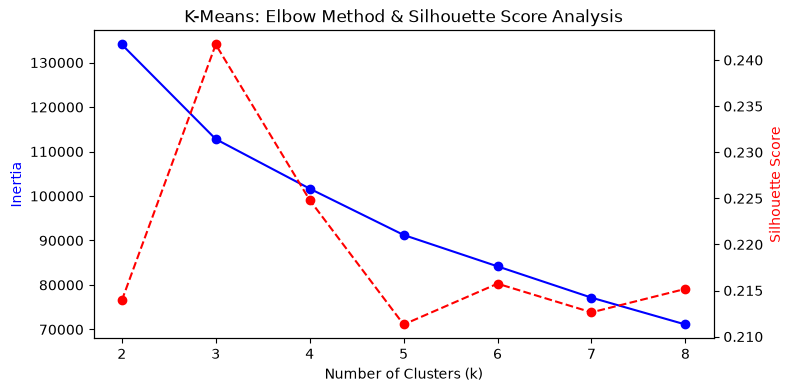

In [108]:
# Elbow & Silhouette Analysis
inertia = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca_proj)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca_proj, labels))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(K_range, inertia, 'bo-', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='b')

ax2 = ax1.twinx()
ax2.plot(K_range, sil_scores, 'ro--', label='Silhouette')
ax2.set_ylabel('Silhouette Score', color='r')
plt.title("K-Means: Elbow Method & Silhouette Score Analysis")
plt.show()

Initialize cluster centroids: Randomly select initial cluster centroids.

In [111]:
# Initialize K-Means model using k-means++
km_model = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
print(km_model)

KMeans(n_clusters=3, n_init=10, random_state=42)


Assign data points to clusters: Assign each data point to the nearest cluster centroid.

In [112]:
# Initial assignment fit
kmeans_labels = km_model.fit_predict(X_pca_proj)
print(kmeans_labels)

[0 2 0 ... 0 2 0]


Recompute cluster centroids: Calculate the new centroids for each cluster based on the assigned data points.

In [113]:
# Extract recomputed cluster centroids
centroids = km_model.cluster_centers_
print("Computed Cluster Centroids Shape:", centroids.shape)

Computed Cluster Centroids Shape: (3, 9)


Iterate until convergence: Repeat previous 2 steps until the cluster assignments stabilize or a maximum number of iterations is reached.

In [114]:
# Check model convergence status
print("K-Means Converged in", km_model.n_iter_, "iterations.")

K-Means Converged in 13 iterations.


Visualize cluster assignments: Plot the data points with different colors or markers to represent the cluster assignments from each clustering algorithm.

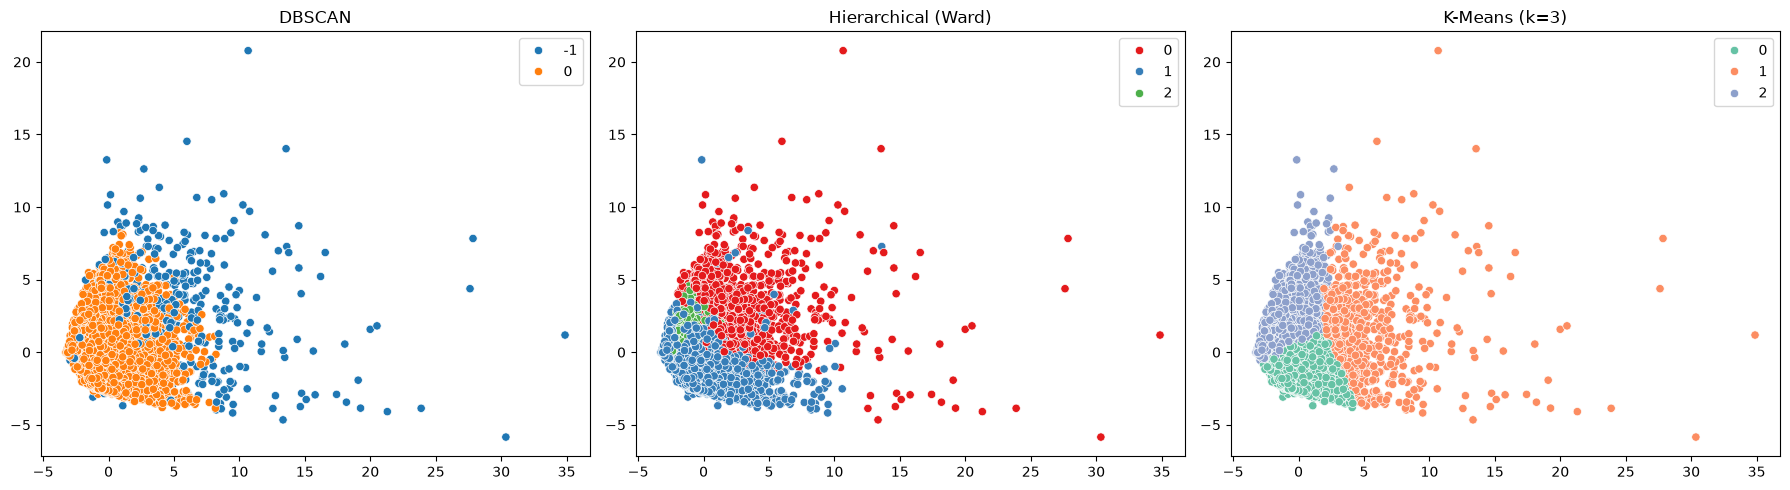

In [115]:
# Comparative visual display
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=pca_2d[:, 0], y=pca_2d[:, 1], hue=dbscan_labels, palette='tab10', ax=axes[0]).set_title('DBSCAN')
sns.scatterplot(x=pca_2d[:, 0], y=pca_2d[:, 1], hue=agg_labels, palette='Set1', ax=axes[1]).set_title('Hierarchical (Ward)')
sns.scatterplot(x=pca_2d[:, 0], y=pca_2d[:, 1], hue=kmeans_labels, palette='Set2', ax=axes[2]).set_title('K-Means (k=3)')

plt.tight_layout()
plt.show()

Compare clustering results: Analyze the similarities and differences between the clusters obtained from hierarchical, non-hierarchical, and DBSCAN.

In [116]:
# Cross-tabulation between K-Means and Hierarchical Clustering
pd.crosstab(pd.Series(kmeans_labels, name='K-Means'), pd.Series(agg_labels, name='Hierarchical'))

Hierarchical,0,1,2
K-Means,,,
0,162,4981,1
1,546,211,0
2,487,948,1614


Evaluate clustering performance: Compare the clustering performance metrics (e.g., silhouette coefficient, Calinski-Harabasz index) for each algorithm.

In [117]:
# Summary comparison metrics table
results = {
    'Algorithm': ['Hierarchical (Ward)', 'K-Means (k=3)'],
    'Silhouette Score': [
        silhouette_score(X_pca_proj, agg_labels),
        silhouette_score(X_pca_proj, kmeans_labels)
    ],
    'Calinski-Harabasz Index': [
        calinski_harabasz_score(X_pca_proj, agg_labels),
        calinski_harabasz_score(X_pca_proj, kmeans_labels)
    ],
    'Davies-Bouldin Index': [
        davies_bouldin_score(X_pca_proj, agg_labels),
        davies_bouldin_score(X_pca_proj, kmeans_labels)
    ]
}

pd.DataFrame(results)

,Algorithm,Silhouette Score,Calinski-Harabasz Index,Davies-Bouldin Index
0,Hierarchical (Ward),0.139684,1316.268881,1.555454
1,K-Means (k=3),0.241689,1919.794498,1.459064


Identify strengths and weaknesses: Determine the strengths and weaknesses of each clustering algorithm based on the results and the characteristics of the data.

**Type your answer here**

Choose the best algorithm: Select the clustering algorithm that provides the most meaningful and accurate results for the specific problem.

**Type your answer here**